In [42]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file path (ensure to use an "r" string for Windows paths to avoid issues with backslashes)
file_path = r"hotel_bookings.csv"

# Load the dataset
hotel_bookings = pd.read_csv(file_path)

# Display the first few rows to confirm successful loading
hotel_bookings.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [43]:
columns = hotel_bookings.columns.tolist()
print(columns)

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [44]:
print(hotel_bookings)

               hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   
2                    July     

In [45]:
missing_data = hotel_bookings.isnull().sum()

print("Missing Data Count:")
print(missing_data[missing_data > 0])

Missing Data Count:
children         4
country        488
agent        16340
company     112593
dtype: int64


In [46]:
print("Country Counts:")
column = "country"
print(hotel_bookings[column].value_counts())
print("\n")

Country Counts:
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64




In [47]:
print("Company Counts:")
column = "company"
print(hotel_bookings[column].value_counts())
print("\n")

Company Counts:
company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
        ... 
104.0      1
531.0      1
160.0      1
413.0      1
386.0      1
Name: count, Length: 352, dtype: int64




In [48]:
print("Agent Counts:")
column = "agent"
print(hotel_bookings[column].value_counts())
print("\n")

Agent Counts:
agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
289.0        1
432.0        1
265.0        1
93.0         1
304.0        1
Name: count, Length: 333, dtype: int64




In [49]:
hotel_bookings['children'] = hotel_bookings['children'].fillna(0)
hotel_bookings['agent'] = hotel_bookings['agent'].fillna(0)
hotel_bookings['company'] = hotel_bookings['company'].fillna(0)
hotel_bookings['country'] = hotel_bookings['country'].fillna('Unknown')

In [50]:
print(hotel_bookings)

               hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   
2                    July     

In [51]:
print("Numerical Summary")
print(hotel_bookings.describe())

categorical_columns = hotel_bookings.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"Value counts for {col}:")
    print(hotel_bookings[col].value_counts())
    print()

Numerical Summary
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%                   38.

In [52]:
# Data Viz

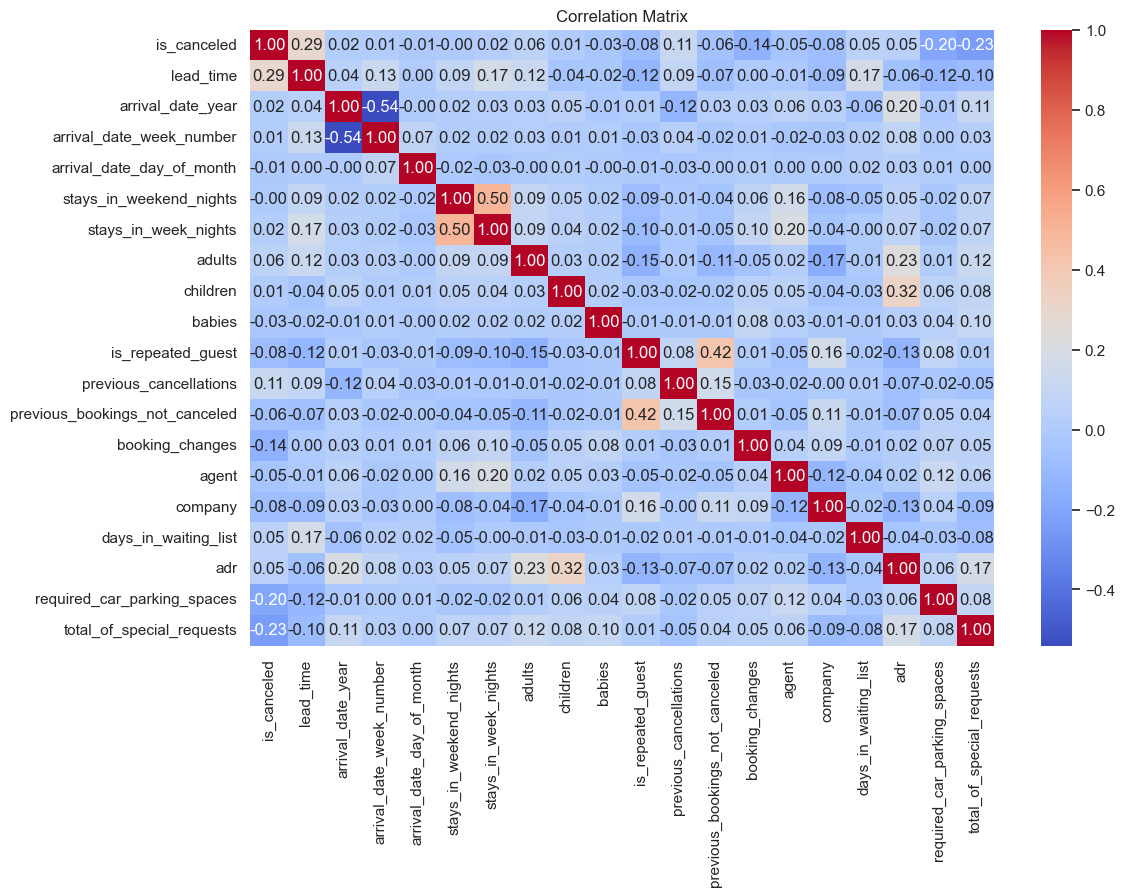

In [53]:
# Correlation Analysis

numeric_columns = hotel_bookings.select_dtypes(include=['float', 'int'])
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_7416/216921118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel_bookings, x='is_canceled', palette='pastel')


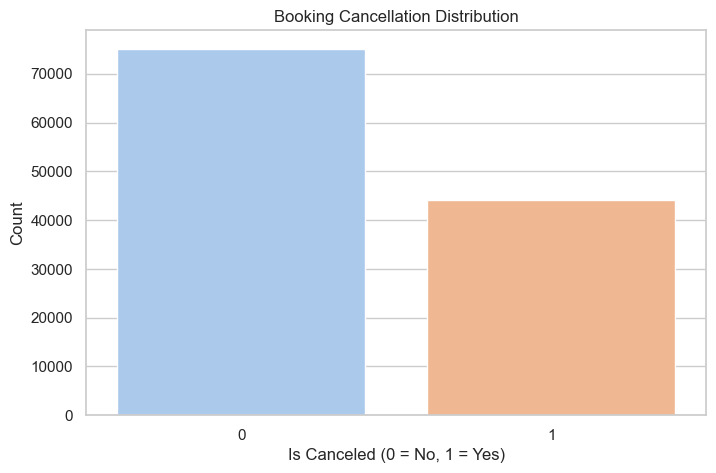

In [54]:
# Booking cancellations
plt.figure(figsize=(8, 5))
sns.countplot(data=hotel_bookings, x='is_canceled', palette='pastel')
plt.title('Booking Cancellation Distribution')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_7416/873816107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hotel_bookings, x='hotel', y='adr', palette='pastel')


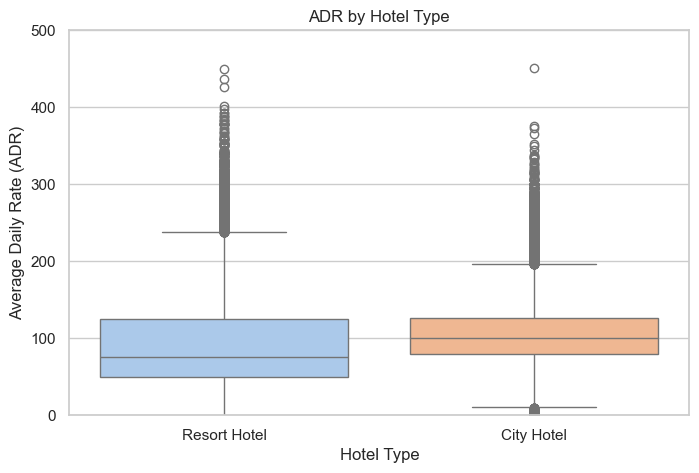

In [55]:
# Average Daily Rate (ADR) by hotel type
plt.figure(figsize=(8, 5))
sns.boxplot(data=hotel_bookings, x='hotel', y='adr', palette='pastel')
plt.title('ADR by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.ylim(0, 500)  # Limit y-axis for better visualization
plt.show()

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_7416/3200128844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hotel_bookings, x='stays_in_weekend_nights', y='stays_in_week_nights', palette='pastel')


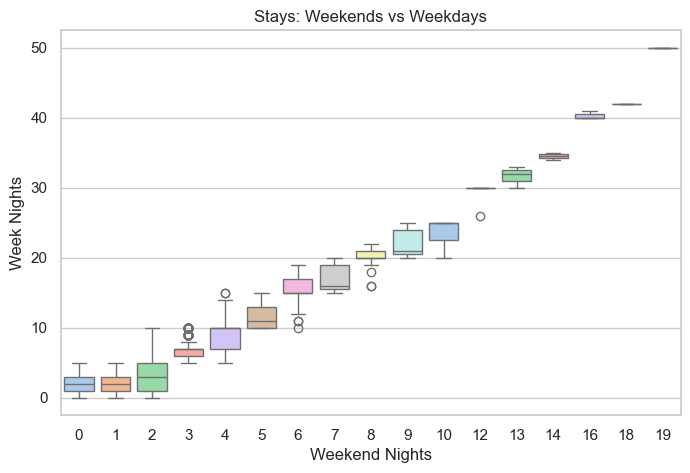

In [56]:
# Stays in weekends vs weekdays
plt.figure(figsize=(8, 5))
sns.boxplot(data=hotel_bookings, x='stays_in_weekend_nights', y='stays_in_week_nights', palette='pastel')
plt.title('Stays: Weekends vs Weekdays')
plt.xlabel('Weekend Nights')
plt.ylabel('Week Nights')
plt.show()

In [57]:
missing_values = hotel_bookings.isnull().sum()

hotel_bookings.drop(columns='company', inplace=True)

negative_adr_count = (hotel_bookings['adr'] < 0).sum()
hotel_data = hotel_bookings[hotel_bookings['adr'] >= 0]

hotel_data['children'] = hotel_data['children'].astype(int)

missing_values, negative_adr_count, hotel_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119389 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119389 non-null  object 
 1   is_canceled                     119389 non-null  int64  
 2   lead_time                       119389 non-null  int64  
 3   arrival_date_year               119389 non-null  int64  
 4   arrival_date_month              119389 non-null  object 
 5   arrival_date_week_number        119389 non-null  int64  
 6   arrival_date_day_of_month       119389 non-null  int64  
 7   stays_in_weekend_nights         119389 non-null  int64  
 8   stays_in_week_nights            119389 non-null  int64  
 9   adults                          119389 non-null  int64  
 10  children                        119389 non-null  int64  
 11  babies                          119389 non-null  int64  
 12  meal                 

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_7416/3174133029.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_data['children'] = hotel_data['children'].astype(int)


(hotel                             0
 is_canceled                       0
 lead_time                         0
 arrival_date_year                 0
 arrival_date_month                0
 arrival_date_week_number          0
 arrival_date_day_of_month         0
 stays_in_weekend_nights           0
 stays_in_week_nights              0
 adults                            0
 children                          0
 babies                            0
 meal                              0
 country                           0
 market_segment                    0
 distribution_channel              0
 is_repeated_guest                 0
 previous_cancellations            0
 previous_bookings_not_canceled    0
 reserved_room_type                0
 assigned_room_type                0
 booking_changes                   0
 deposit_type                      0
 agent                             0
 company                           0
 days_in_waiting_list              0
 customer_type                     0
 

Dataset Exploration

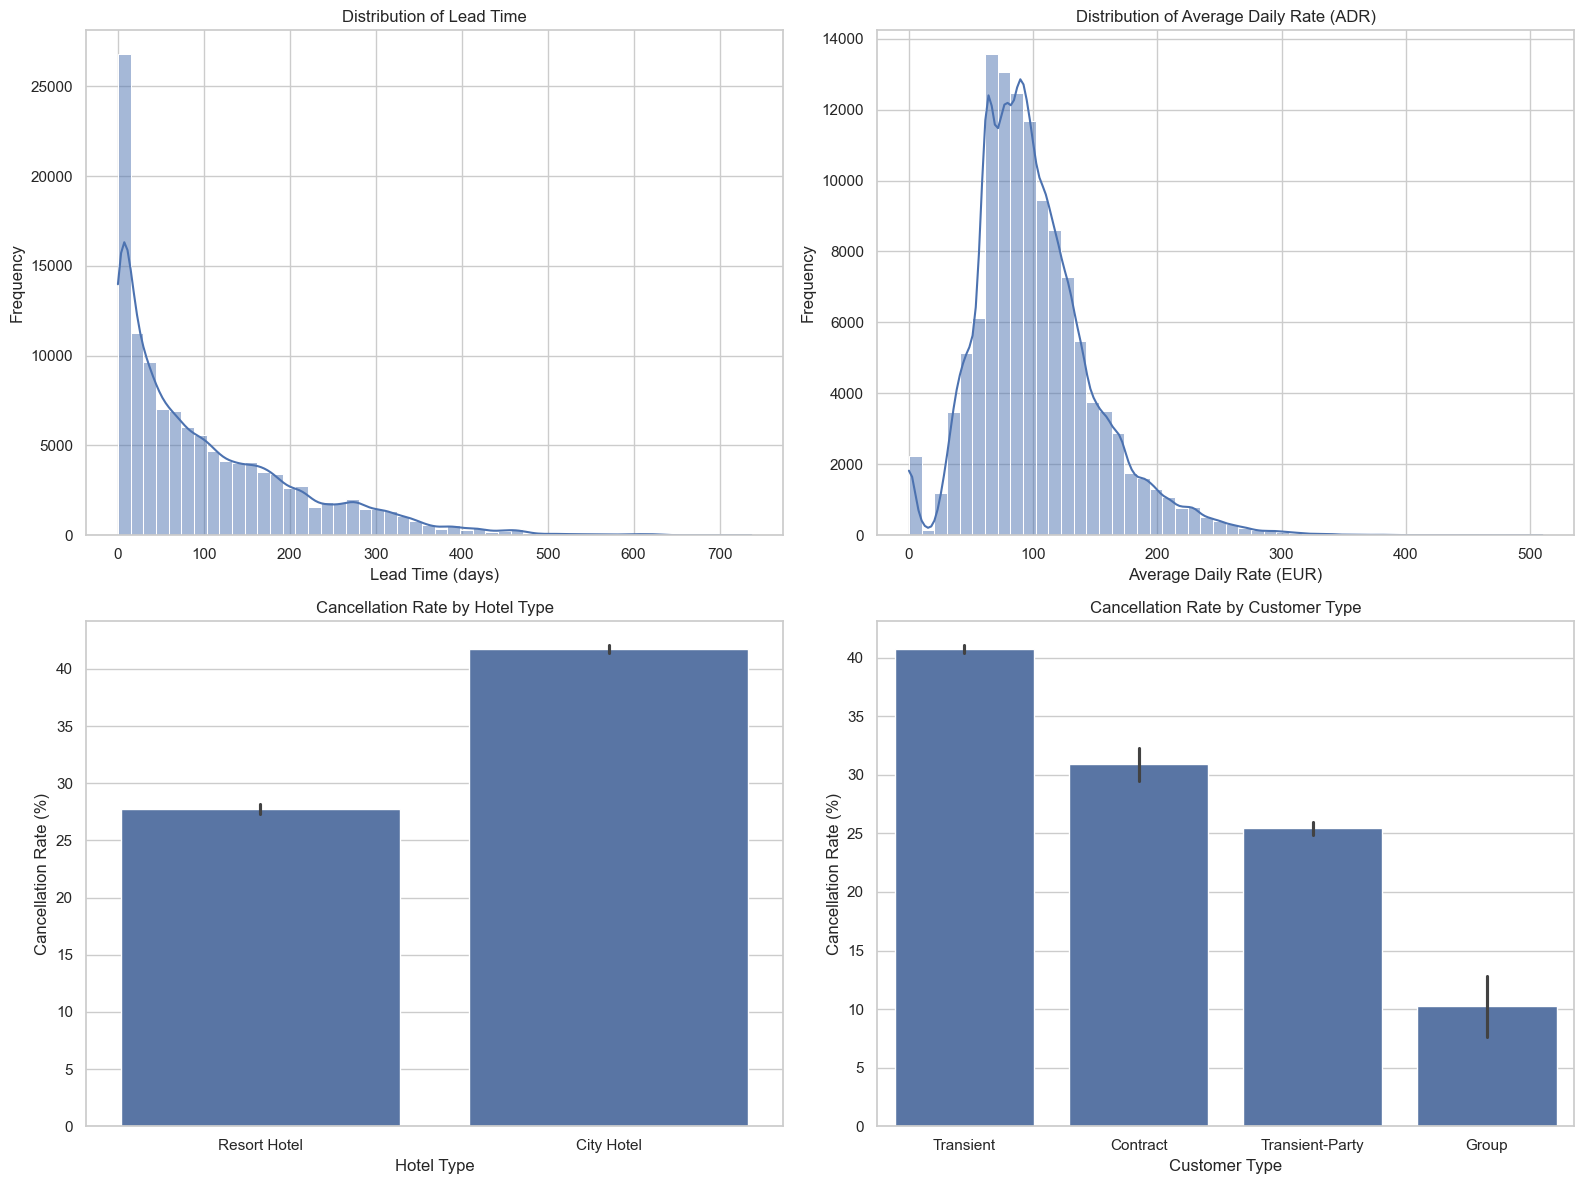

In [58]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of 'lead_time'
sns.histplot(hotel_data['lead_time'], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Distribution of Lead Time')
axes[0, 0].set_xlabel('Lead Time (days)')
axes[0, 0].set_ylabel('Frequency')

# Distribution of 'adr' (average daily rate)
sns.histplot(hotel_data[hotel_data['adr'] < 1000]['adr'], bins=50, ax=axes[0, 1], kde=True)  # filtering extreme values for better visualization
axes[0, 1].set_title('Distribution of Average Daily Rate (ADR)')
axes[0, 1].set_xlabel('Average Daily Rate (EUR)')
axes[0, 1].set_ylabel('Frequency')

# Cancellation rate vs hotel type
sns.barplot(x="hotel", y="is_canceled", data=hotel_data, estimator=lambda x: sum(x)*100/len(x), ax=axes[1, 0])
axes[1, 0].set_title('Cancellation Rate by Hotel Type')
axes[1, 0].set_xlabel('Hotel Type')
axes[1, 0].set_ylabel('Cancellation Rate (%)')

# Cancellation rate vs customer type
sns.barplot(x="customer_type", y="is_canceled", data=hotel_data, estimator=lambda x: sum(x)*100/len(x), ax=axes[1, 1])
axes[1, 1].set_title('Cancellation Rate by Customer Type')
axes[1, 1].set_xlabel('Customer Type')
axes[1, 1].set_ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()

Feature Engineering

In [59]:
import pandas as pd

# Feature Engineering
# Total Guests
hotel_data['total_guests'] = hotel_data['adults'] + hotel_data['children'] + hotel_data['babies']

# Total Stay Nights
hotel_data['total_stay_nights'] = hotel_data['stays_in_weekend_nights'] + hotel_data['stays_in_week_nights']

# Booking Total Cost (assuming the adr is for all guests per night)
hotel_data['booking_total_cost'] = hotel_data['adr'] * hotel_data['total_stay_nights']

# Is Family
hotel_data['is_family'] = ((hotel_data['children'] > 0) | (hotel_data['babies'] > 0)).astype(int)

# Is Long Stay (more than 7 nights)
hotel_data['is_long_stay'] = (hotel_data['total_stay_nights'] > 7).astype(int)

# Lead Time Category
bins = [0, 7, 30, 180, float('inf')]
labels = ['Very Short', 'Short', 'Medium', 'Long']
hotel_data['lead_time_category'] = pd.cut(hotel_data['lead_time'], bins=bins, labels=labels, right=False)

# Simplify meal types if necessary
meal_counts = hotel_data['meal'].value_counts()
common_meals = meal_counts[meal_counts > 50].index.tolist()  # Filtering meals with more than 50 occurrences
hotel_data['meal'] = hotel_data['meal'].apply(lambda x: x if x in common_meals else 'Other')

# Save the modified dataset
hotel_data.to_csv('modified_hotel_bookings.csv', index=False)

# Display the head of the modified dataset with new features
print(hotel_data.head())


/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_7416/1675098937.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_data['total_guests'] = hotel_data['adults'] + hotel_data['children'] + hotel_data['babies']
/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_7416/1675098937.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_data['total_stay_nights'] = hotel_data['stays_in_weekend_nights'] + hotel_data['stays_in_week_nights']
/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ip

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
1                        0        

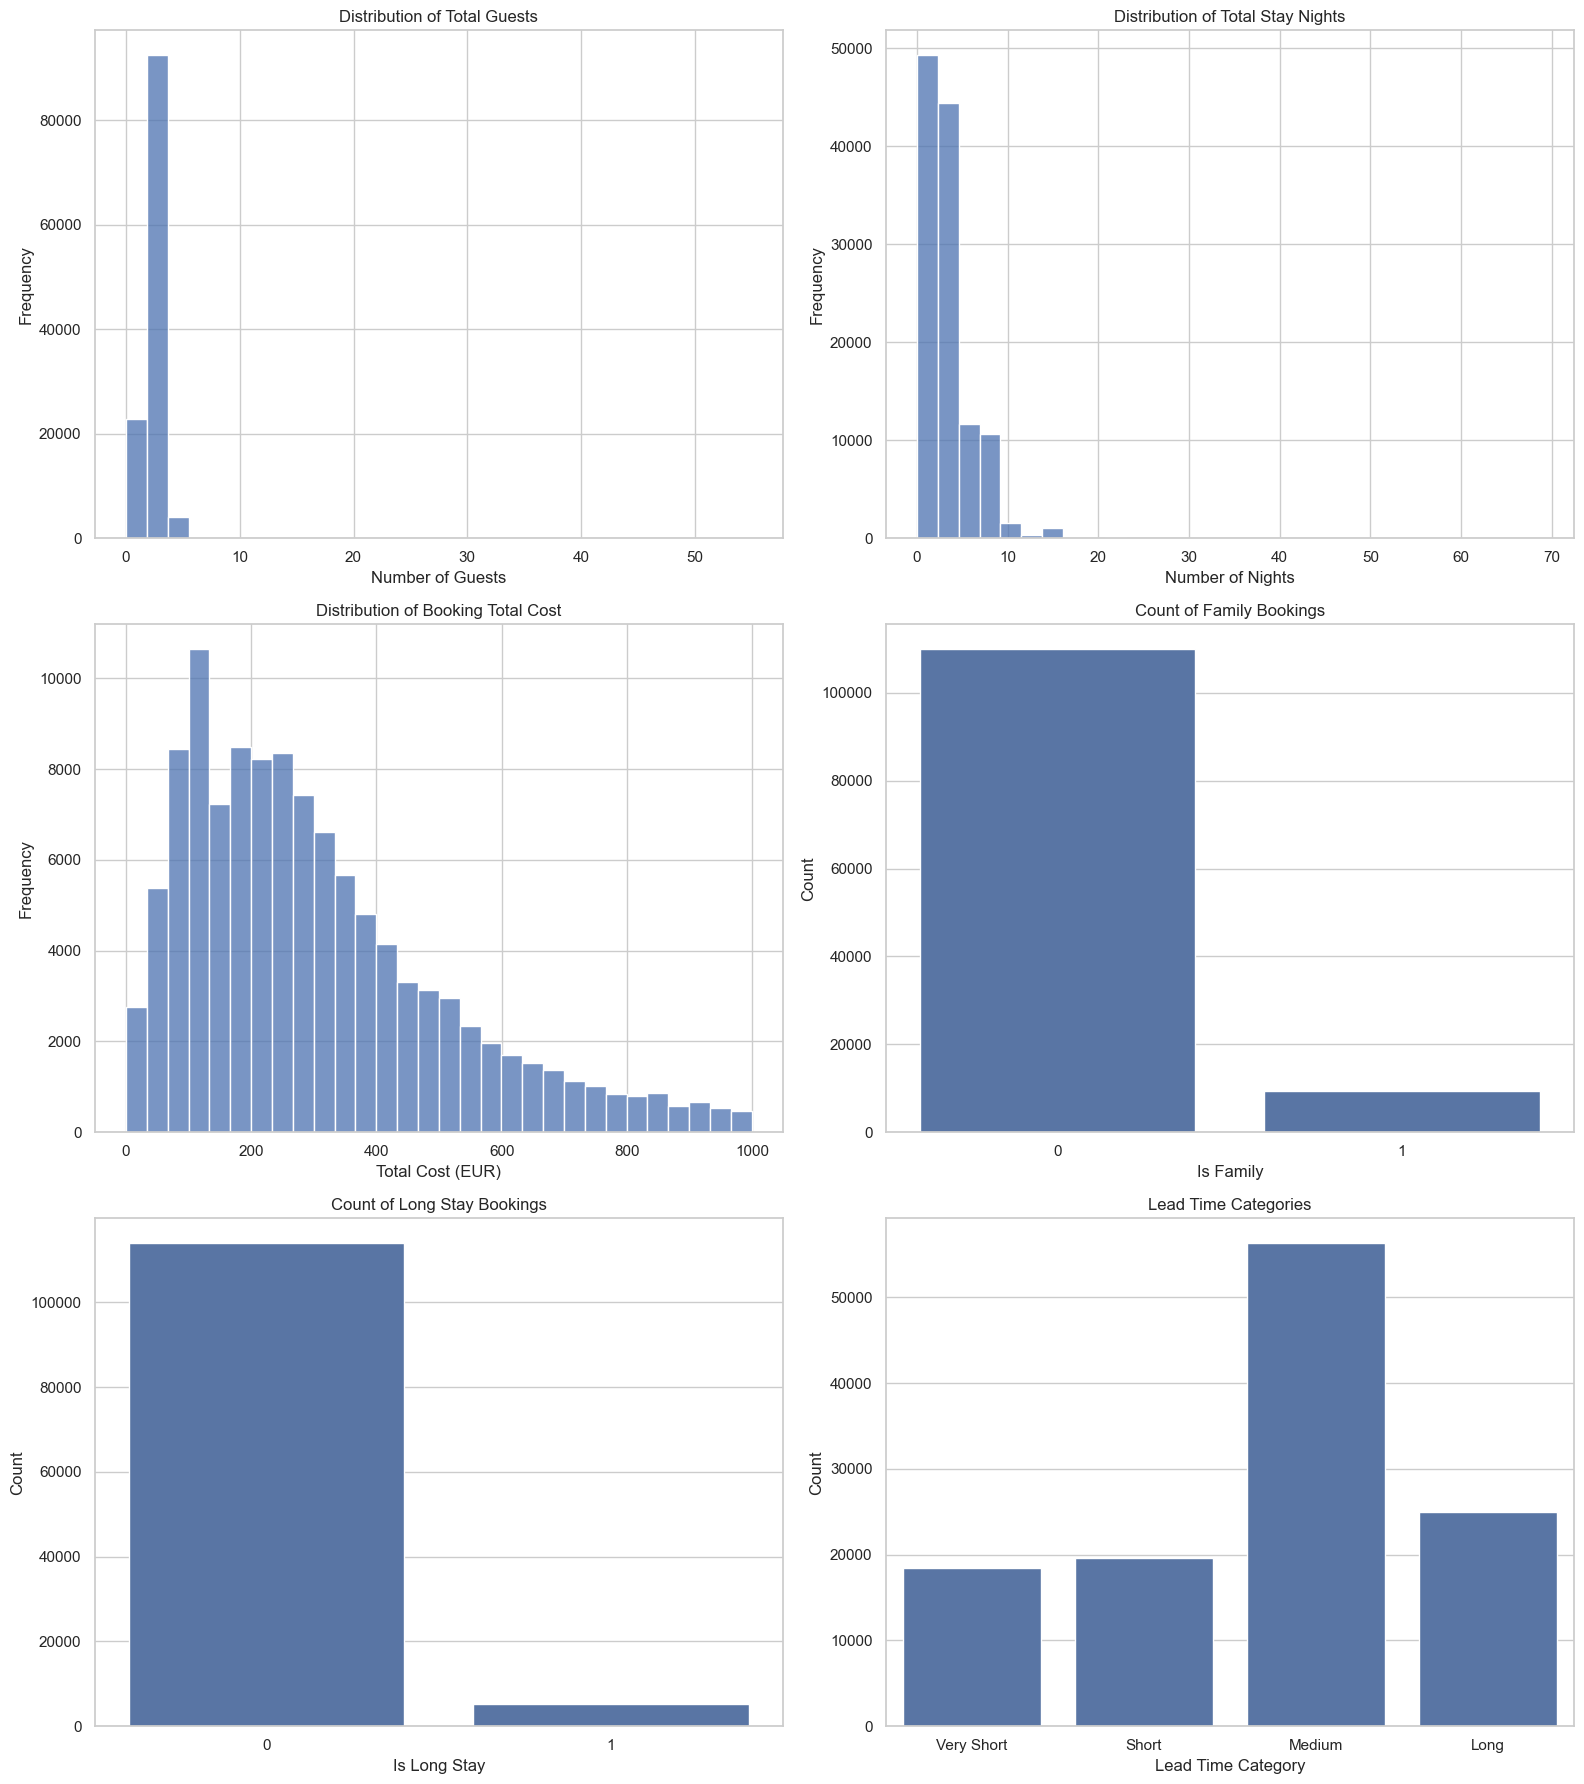

In [60]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Total Guests
sns.histplot(hotel_data['total_guests'], bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Total Guests')
axes[0, 0].set_xlabel('Number of Guests')
axes[0, 0].set_ylabel('Frequency')

# Total Stay Nights
sns.histplot(hotel_data['total_stay_nights'], bins=30, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Total Stay Nights')
axes[0, 1].set_xlabel('Number of Nights')
axes[0, 1].set_ylabel('Frequency')

# Booking Total Cost
sns.histplot(hotel_data[hotel_data['booking_total_cost'] < 1000]['booking_total_cost'], bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Booking Total Cost')
axes[1, 0].set_xlabel('Total Cost (EUR)')
axes[1, 0].set_ylabel('Frequency')

# Count of Family
sns.countplot(x='is_family', data=hotel_data, ax=axes[1, 1])
axes[1, 1].set_title('Count of Family Bookings')
axes[1, 1].set_xlabel('Is Family')
axes[1, 1].set_ylabel('Count')

# Count of Long Stay
sns.countplot(x='is_long_stay', data=hotel_data, ax=axes[2, 0])
axes[2, 0].set_title('Count of Long Stay Bookings')
axes[2, 0].set_xlabel('Is Long Stay')
axes[2, 0].set_ylabel('Count')

# Lead Time Category
sns.countplot(x='lead_time_category', data=hotel_data, ax=axes[2, 1])
axes[2, 1].set_title('Lead Time Categories')
axes[2, 1].set_xlabel('Lead Time Category')
axes[2, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Model Preparation

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Features and target variable
features = hotel_bookings.drop(['is_canceled', 'adr'], axis=1)  # exclude the target variables
targets = hotel_bookings[['is_canceled']]  # cancellation and average daily rate for revenue

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=42)

categorical_cols = [cname for cname in X_train.columns if X_train[cname].dtype == "object" or cname == 'arrival_date_month']
numerical_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['int64', 'float64'] and cname not in ['arrival_date_month']]

In [62]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_transformer = StandardScaler()  # Scale numerical variables
categorical_transformer = OneHotEncoder(handle_unknown='ignore')  # One-hot encode categorical variables

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier

# Set up a dummy classifier for baseline comparison
dummy_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

# Perform cross-validation on the dummy classifier
dummy_scores = cross_val_score(dummy_clf, features, targets, cv=5, scoring='accuracy')
print("Dummy classifier scores:", dummy_scores)
print("Average score for dummy classifier:", dummy_scores.mean())


Dummy classifier scores: [0.62961722 0.62957534 0.62957534 0.62957534 0.62957534]
Average score for dummy classifier: 0.6295837172292486


In [64]:
from sklearn.linear_model import LogisticRegression

logistic_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=500))
])

In [65]:
# Training of Cancellation model

from sklearn.metrics import accuracy_score, classification_report

# Fit the model on the training data
logistic_model_pipeline.fit(X_train, y_train)

# Predict on the test data
y_pred = logistic_model_pipeline.predict(X_test)

# Evaluate the model
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy on test data: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14907
           1       1.00      1.00      1.00      8971

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [66]:
#cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(logistic_model_pipeline, features, targets, cv=5, scoring='accuracy')
print("Cross-validated scores:", scores)
print("Average score:", scores.mean())

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

Cross-validated scores: [1.         1.         0.99928805 1.         1.        ]
Average score: 0.9998576095150348


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [67]:
#checking for duplicate rows

train_rows = X_train.apply(lambda x: '_'.join(x.astype(str)), axis=1)
test_rows = X_test.apply(lambda x: '_'.join(x.astype(str)), axis=1)
overlap = set(train_rows) & set(test_rows)
print("Number of overlapping rows:", len(overlap))

Number of overlapping rows: 4035


In [68]:
print(len(hotel_bookings))

119390


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Data setup
data = hotel_data
data_cleaned = data.drop_duplicates()
X = data_cleaned[['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
                  'previous_cancellations', 'days_in_waiting_list', 'adr',
                  'required_car_parking_spaces', 'total_of_special_requests']]
y = data_cleaned['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build and train pipeline
preprocessor = StandardScaler()
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])
model_pipeline.fit(X_train, y_train)

# Evaluate pipeline
y_pred = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model_pipeline.predict_proba(X_test)[:, 1])

print(f"Accuracy: {accuracy}")
print(f"ROC-AUC: {roc_auc}")
print(classification_report(y_test, y_pred))

# Extract and display feature importance
importances = model_pipeline.named_steps['classifier'].coef_[0]
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importance = dict(zip(feature_names, importances))
sorted_features = sorted(feature_importance.items(), key=lambda x: abs(x[1]), reverse=True)

print("Top features by importance:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance}")


Accuracy: 0.6514475340427966
ROC-AUC: 0.721678864773638
              precision    recall  f1-score   support

           0       0.85      0.64      0.73     19111
           1       0.41      0.69      0.52      7106

    accuracy                           0.65     26217
   macro avg       0.63      0.66      0.62     26217
weighted avg       0.73      0.65      0.67     26217

Top features by importance:
required_car_parking_spaces: -2.7619637540057638
adr: 0.3806369024245108
lead_time: 0.37781811604625043
total_of_special_requests: -0.3699704435308634
previous_cancellations: 0.3487972752295652
adults: 0.1303477704497936
stays_in_week_nights: 0.06092228364793283
days_in_waiting_list: -0.04114428714008615
stays_in_weekend_nights: 0.006917470593438309


In [70]:
columns = data.columns.tolist()
print(columns)

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'total_guests', 'total_stay_nights', 'booking_total_cost', 'is_family', 'is_long_stay', 'lead_time_category']


In [71]:
columns = data.columns.tolist()
print(columns)

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'total_guests', 'total_stay_nights', 'booking_total_cost', 'is_family', 'is_long_stay', 'lead_time_category']


In [72]:
# Extract the coefficients from the trained Logistic Regression model
importances = model_pipeline.named_steps['classifier'].coef_[0]

# Extract the feature names from the preprocessor step
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Map feature names to their corresponding coefficients
feature_importance = dict(zip(feature_names, importances))

# Sort the features by absolute importance (highest to lowest)
sorted_features = sorted(feature_importance.items(), key=lambda x: abs(x[1]), reverse=True)

# Display the top 10 features by importance
print("Top features by importance:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance}")


Top features by importance:
required_car_parking_spaces: -2.7619637540057638
adr: 0.3806369024245108
lead_time: 0.37781811604625043
total_of_special_requests: -0.3699704435308634
previous_cancellations: 0.3487972752295652
adults: 0.1303477704497936
stays_in_week_nights: 0.06092228364793283
days_in_waiting_list: -0.04114428714008615
stays_in_weekend_nights: 0.006917470593438309


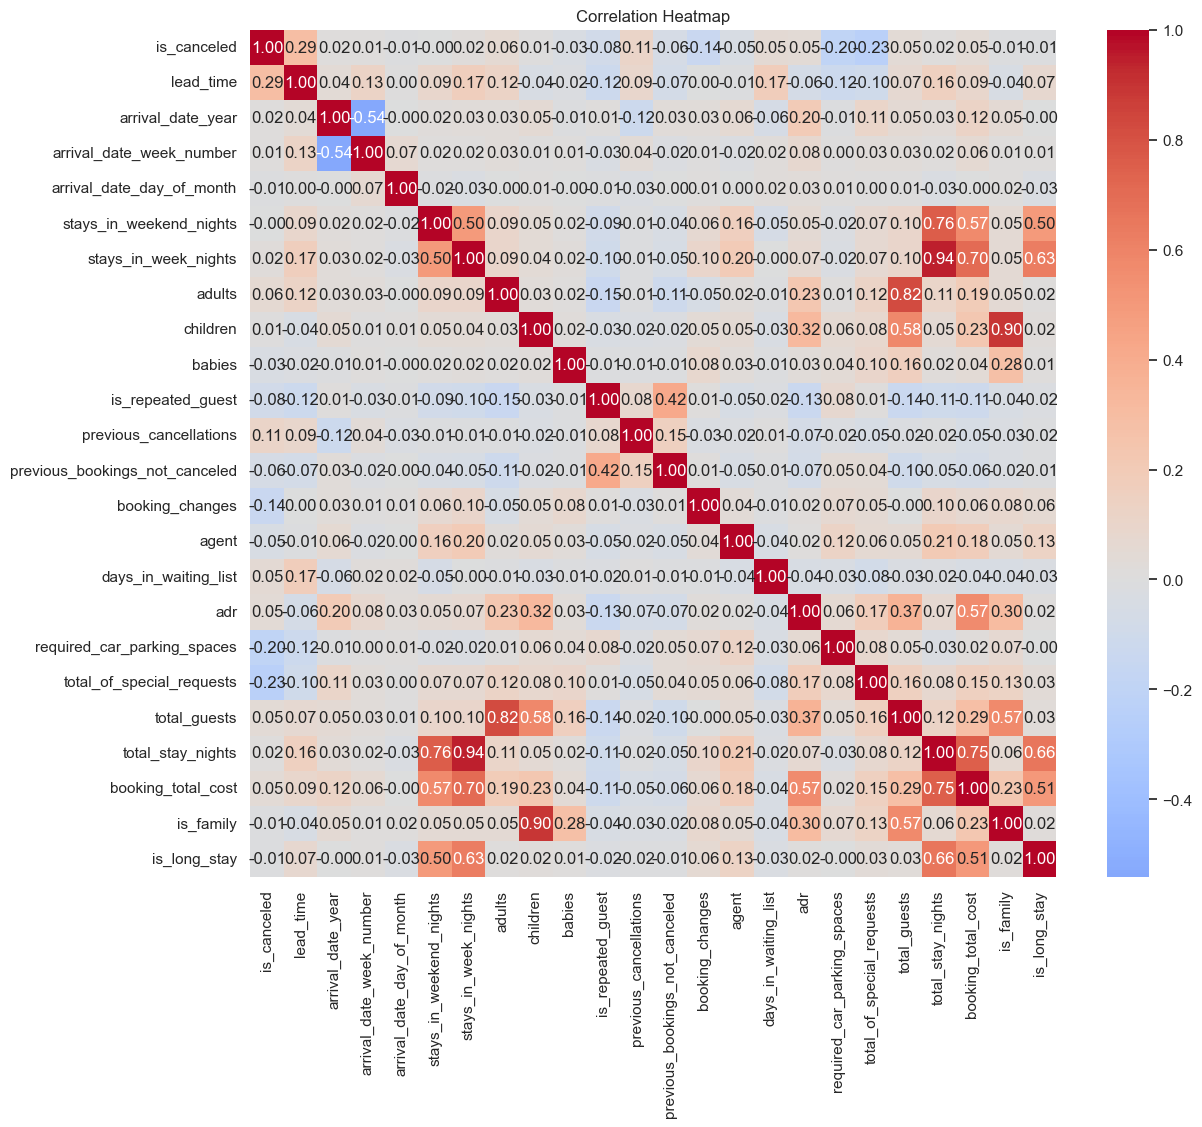

In [73]:
import numpy as np

# Keep Only Numeric Columns
numeric_df = data.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

# Plot the Heatmap
plt.figure(figsize=(13, 11))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [74]:
cancellation_correlations = correlation_matrix['is_canceled']
print(cancellation_correlations)

threshold = 0.1

low_correlation_features = cancellation_correlations[abs(cancellation_correlations) < threshold].index.tolist()
print("Features with low correlation to 'is_canceled':", low_correlation_features)


is_canceled                       1.000000
lead_time                         0.293130
arrival_date_year                 0.016668
arrival_date_week_number          0.008140
arrival_date_day_of_month        -0.006138
stays_in_weekend_nights          -0.001771
stays_in_week_nights              0.024777
adults                            0.060019
children                          0.005035
babies                           -0.032492
is_repeated_guest                -0.084769
previous_cancellations            0.110132
previous_bookings_not_canceled   -0.057350
booking_changes                  -0.144368
agent                            -0.046518
days_in_waiting_list              0.054185
adr                               0.047544
required_car_parking_spaces      -0.195500
total_of_special_requests        -0.234663
total_guests                      0.046522
total_stay_nights                 0.017796
booking_total_cost                0.046554
is_family                        -0.012778
is_long_sta

In [75]:
# Preprocess the test data using the same pipeline
X_test_preprocessed = model_pipeline.named_steps['preprocessor'].transform(X_test)

# Make predictions
predicted_labels = model_pipeline.predict(X_test_preprocessed)  # Predicted classes
predicted_probabilities = model_pipeline.predict_proba(X_test_preprocessed)[:, 1]  # Predicted probabilities

# Add predictions to the test data for saving
X_test_with_predictions = X_test.copy()
X_test_with_predictions['Predicted_Label'] = predicted_labels
X_test_with_predictions['Predicted_Probability'] = predicted_probabilities

# Save predictions to a CSV file
output_file_path = "test_predictions.csv"
X_test_with_predictions.to_csv(output_file_path, index=False)

print(f"Predictions saved to {output_file_path}")


Predictions saved to test_predictions.csv


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [77]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Define the dataset (replace with your actual dataset)
data_cleaned = data.drop_duplicates()  # Remove duplicates if needed

# Select features and target
X = data_cleaned[['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
                  'previous_cancellations', 'days_in_waiting_list', 'adr',
                  'required_car_parking_spaces', 'total_of_special_requests']]
y = data_cleaned['is_canceled']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data
preprocessor = StandardScaler()
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Define models to evaluate
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Store results
results = []

# Iterate over models
for model_name, model in models.items():
    # Create a pipeline for preprocessing and modeling
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else "N/A"
    results.append((model_name, accuracy, roc_auc))
    
    # Print classification report for each model
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy}")
    print(f"ROC-AUC: {roc_auc}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Print the summary of all models
print("\nSummary of Model Performances:")
print(results_df)

# Save results to a CSV for reference
results_df.to_csv("model_comparison_results.csv", index=False)
print("Model comparison results saved to 'model_comparison_results.csv'")


Model: Logistic Regression
Accuracy: 0.6514475340427966
ROC-AUC: 0.721678864773638
              precision    recall  f1-score   support

           0       0.85      0.64      0.73     19111
           1       0.41      0.69      0.52      7106

    accuracy                           0.65     26217
   macro avg       0.63      0.66      0.62     26217
weighted avg       0.73      0.65      0.67     26217

--------------------------------------------------
Model: Random Forest
Accuracy: 0.7523744135484609
ROC-AUC: 0.7634384302599552
              precision    recall  f1-score   support

           0       0.80      0.88      0.84     19111
           1       0.56      0.41      0.47      7106

    accuracy                           0.75     26217
   macro avg       0.68      0.64      0.66     26217
weighted avg       0.73      0.75      0.74     26217

--------------------------------------------------
Model: Gradient Boosting
Accuracy: 0.7617576381737041
ROC-AUC: 0.7691790386655306
 

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:33:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


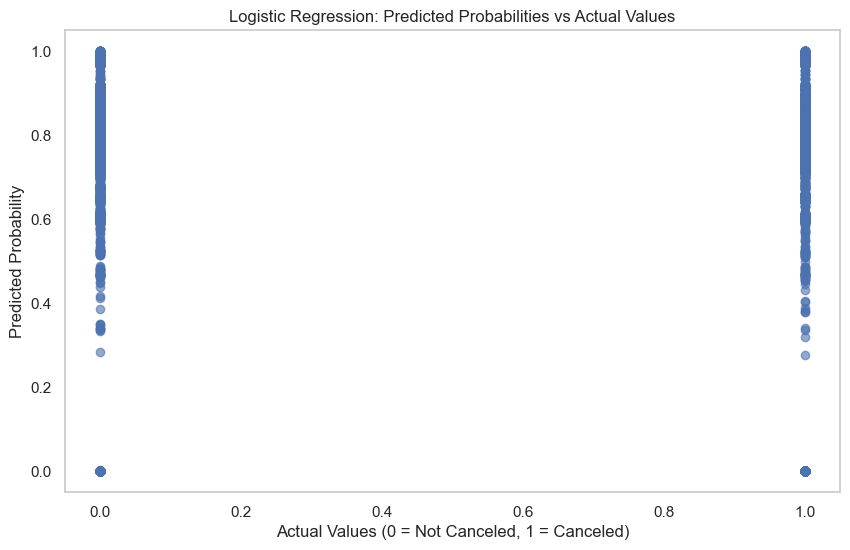

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the predictions and actual values
logistic_predictions = pd.read_csv(r"test_predictions.csv")  # Update with your actual file path
original_data = pd.read_csv("hotel_bookings.csv")  # Adjust path as needed

# Ensure the index alignment to add the actual values
logistic_predictions['is_canceled'] = original_data.loc[logistic_predictions.index, 'is_canceled']

# Check if alignment worked
if 'is_canceled' not in logistic_predictions.columns:
    raise ValueError("Failed to add the 'is_canceled' column to the predictions.")

# Extract actual and predicted values
actual_values = logistic_predictions['is_canceled']
predicted_probabilities = logistic_predictions['Predicted_Probability']

# Plot the comparison
plt.figure(figsize=(10, 6))
plt.scatter(actual_values, predicted_probabilities, alpha=0.6)
plt.title("Logistic Regression: Predicted Probabilities vs Actual Values")
plt.xlabel("Actual Values (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Predicted Probability")
plt.grid()
plt.show()


In [79]:
# Import the necessary library for XGBoost
from xgboost import XGBClassifier

# Initialize the XGBoost model
xgboost_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Fit the model on the training data
xgboost_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = xgboost_model.predict(X_test_scaled)  # Predicted labels
y_pred_proba = xgboost_model.predict_proba(X_test_scaled)[:, 1]  # Predicted probabilities

# Combine predictions with the test data for saving
X_test_with_predictions = X_test.copy()
X_test_with_predictions['Predicted_Label'] = y_pred
X_test_with_predictions['Predicted_Probability'] = y_pred_proba

# Save predictions to a CSV file
output_file_path = "xgboost_predictions.csv"
X_test_with_predictions.to_csv(output_file_path, index=False)

print(f"Predictions using XGBoost model saved to {output_file_path}")


Predictions using XGBoost model saved to xgboost_predictions.csv


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:34:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85     19111
           1       0.63      0.36      0.46      7106

    accuracy                           0.77     26217
   macro avg       0.71      0.64      0.66     26217
weighted avg       0.75      0.77      0.75     26217



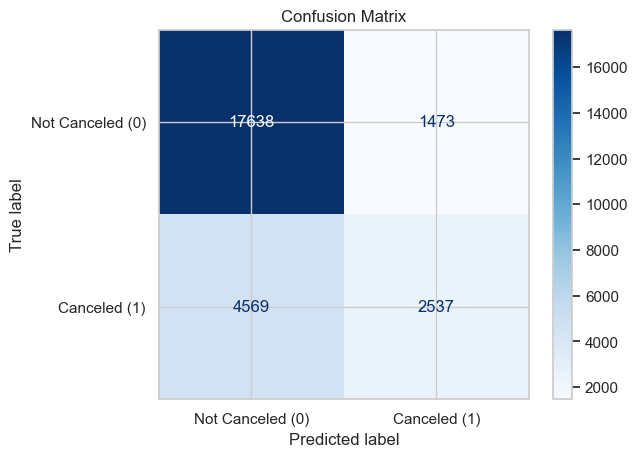

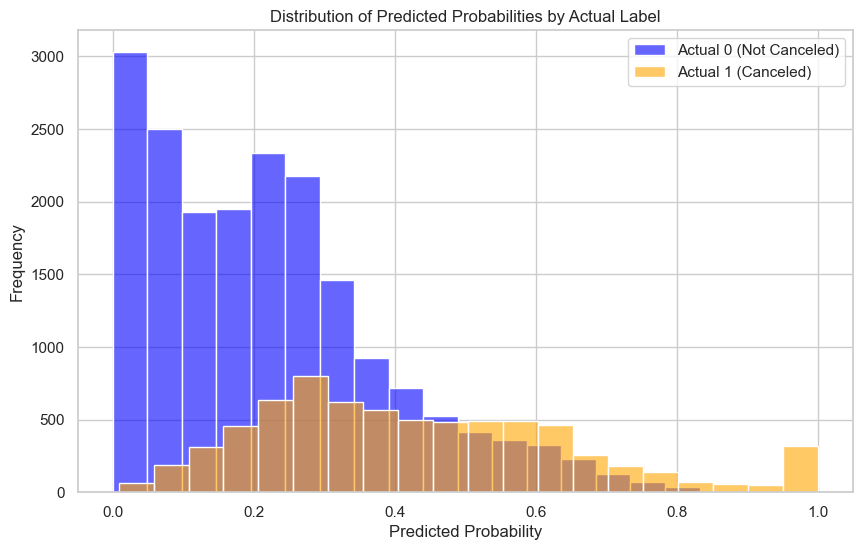

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you have `y_test` (actual labels) and `y_pred` (predicted labels) already
# Also assuming `y_pred_proba` contains the predicted probabilities for the positive class (label 1)

# 1. Generate classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Not Canceled (0)', 'Canceled (1)'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 2. Visualize Predicted Probabilities
# Combine predicted probabilities with actual labels for visualization
probability_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Probability': y_pred_proba
})

# Create histograms for predicted probabilities for both classes
plt.figure(figsize=(10, 6))
sns.histplot(data=probability_df[probability_df['Actual_Label'] == 0], 
             x='Predicted_Probability', 
             bins=20, color='blue', alpha=0.6, label='Actual 0 (Not Canceled)')
sns.histplot(data=probability_df[probability_df['Actual_Label'] == 1], 
             x='Predicted_Probability', 
             bins=20, color='orange', alpha=0.6, label='Actual 1 (Canceled)')
plt.title("Distribution of Predicted Probabilities by Actual Label")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Prepare the dataset
data_cleaned = data.drop_duplicates()  # Assuming `data` is already loaded
X = data_cleaned[['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
                  'previous_cancellations', 'days_in_waiting_list', 'adr', 
                  'required_car_parking_spaces', 'total_of_special_requests']]
y = data_cleaned['is_canceled']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='roc_auc', cv=3, verbose=1)
grid_search.fit(X_train_balanced, y_train_balanced)

# Best model from GridSearchCV
best_xgb = grid_search.best_estimator_

# Evaluate on the test set
y_pred = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {accuracy}")
print(f"ROC-AUC: {roc_auc}")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Canceled', 'Canceled'], 
            yticklabels=['Not Canceled', 'Canceled'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Histogram for Predicted Probabilities
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_proba[y_test == 0], color="blue", label="Actual 0 (Not Canceled)", kde=True, stat="density", bins=25)
sns.histplot(y_pred_proba[y_test == 1], color="orange", label="Actual 1 (Canceled)", kde=True, stat="density", bins=25)
plt.title("Distribution of Predicted Probabilities by Actual Label")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

# Save predictions
X_test_with_predictions = X_test.copy()
X_test_with_predictions['Actual_Label'] = y_test.values
X_test_with_predictions['Predicted_Label'] = y_pred
X_test_with_predictions['Predicted_Probability'] = y_pred_proba
X_test_with_predictions.to_csv("xgboost_predictions_optimized.csv", index=False)

print("Predictions saved to 'xgboost_predictions_optimized.csv'")


Fitting 3 folds for each of 54 candidates, totalling 162 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:35:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:35:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:35:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:35:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

In [ ]:
# Combine year, month, and day into a single datetime column
data['arrival_date'] = pd.to_datetime(
    data['arrival_date_year'].astype(str) + '-' +
    data['arrival_date_month'] + '-' +
    data['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

# Verify the new column
print(data[['arrival_date', 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month']].head())


21:40:35 - cmdstanpy - INFO - Chain [1] start processing
21:40:36 - cmdstanpy - INFO - Chain [1] done processing


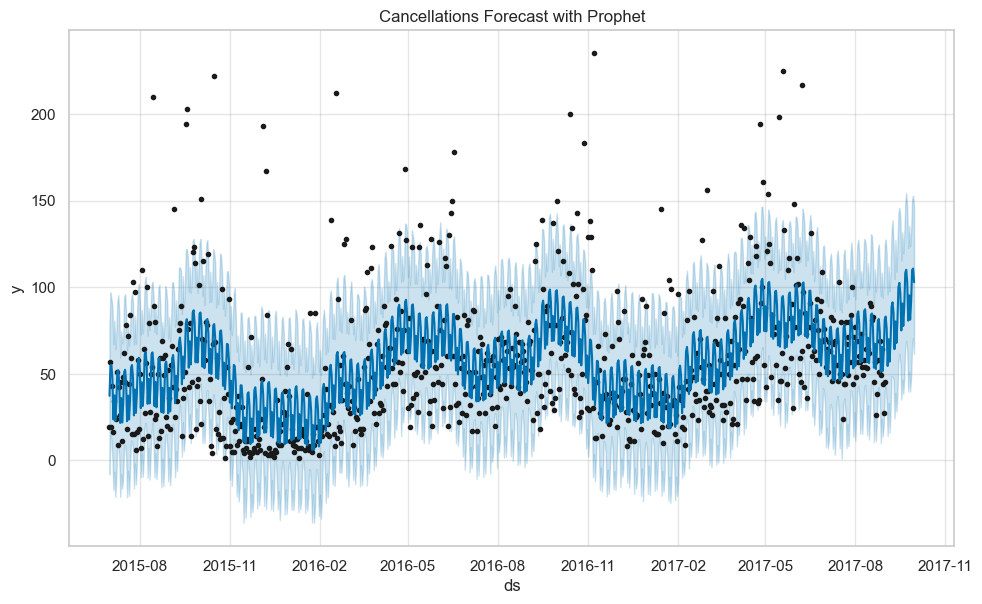

In [94]:
from prophet import Prophet
# Group by arrival_date and calculate cancellations
time_series = data.groupby('arrival_date')['is_canceled'].sum().reset_index()
time_series.columns = ['ds', 'y']  # Prophet requires columns 'ds' (date) and 'y' (value)

# Initialize and fit the Prophet model
model = Prophet()
model.fit(time_series)

# Create a future dataframe and make predictions
future = model.make_future_dataframe(periods=30)  # Predict for the next 30 days
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)
plt.title("Cancellations Forecast with Prophet")
plt.show()


In [96]:
xgb_lr_predictions = X_test_with_predictions
if 'is_canceled' not in xgb_lr_predictions.columns:
    print("Adding 'is_canceled' from the original data.")
    xgb_lr_predictions['is_canceled'] = data.loc[X_test.index, 'is_canceled']


Adding 'is_canceled' from the original data.


Performance Comparison:
Prophet - MAE: 23.32605242642136, MSE: 1074.2321764674023
XGBoost/Logistic Regression - MAE: 42.78361511230469, MSE: 3131.478515625


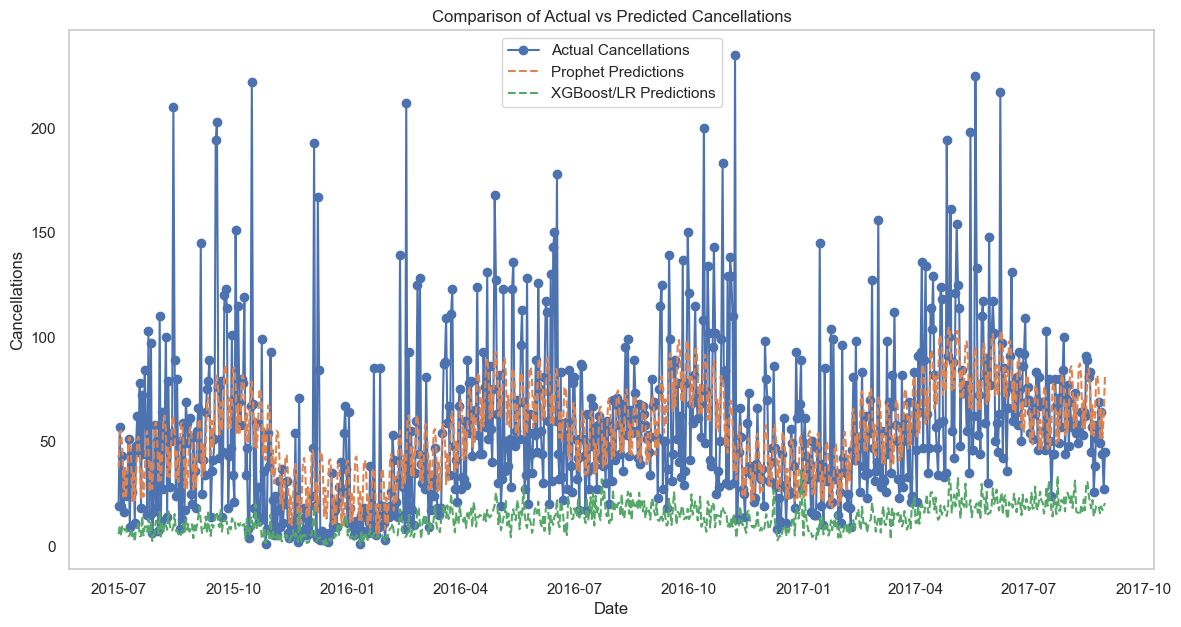

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Step 1: Prepare Prophet Predictions
prophet_actual = time_series  # Actual cancellations (used to fit Prophet)
prophet_predictions = forecast[['ds', 'yhat']].copy()
prophet_predictions = prophet_predictions.merge(prophet_actual, on='ds', how='inner')  # Align actual with predictions
prophet_mae = mean_absolute_error(prophet_predictions['y'], prophet_predictions['yhat'])
prophet_mse = mean_squared_error(prophet_predictions['y'], prophet_predictions['yhat'])

# Step 2: Prepare XGBoost and Logistic Regression Predictions
# Assuming X_test_with_predictions contains the date ('arrival_date') and predictions
xgb_lr_predictions = X_test_with_predictions.copy()
xgb_lr_predictions['arrival_date'] = data.loc[X_test.index, 'arrival_date']  # Map dates to predictions

# Ensure 'is_canceled' column exists
if 'is_canceled' not in xgb_lr_predictions.columns:
    print("Adding 'is_canceled' from the original data.")
    xgb_lr_predictions['is_canceled'] = data.loc[X_test.index, 'is_canceled']

xgb_lr_aggregated = xgb_lr_predictions.groupby('arrival_date').agg({
    'is_canceled': 'sum',  # Actual cancellations
    'Predicted_Probability': 'sum'  # Predicted cancellations (for comparison)
}).reset_index()

# Step 3: Merge Results for Comparison
comparison = prophet_predictions.merge(
    xgb_lr_aggregated,
    left_on='ds',
    right_on='arrival_date',
    suffixes=('_prophet', '_xgb_lr'),
    how='inner'
)

# Step 4: Calculate Metrics for XGBoost/Logistic Regression
xgb_lr_mae = mean_absolute_error(comparison['y'], comparison['Predicted_Probability'])
xgb_lr_mse = mean_squared_error(comparison['y'], comparison['Predicted_Probability'])

# Step 5: Print and Compare Results
print("Performance Comparison:")
print(f"Prophet - MAE: {prophet_mae}, MSE: {prophet_mse}")
print(f"XGBoost/Logistic Regression - MAE: {xgb_lr_mae}, MSE: {xgb_lr_mse}")

# Step 6: Visualize the Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(comparison['ds'], comparison['y'], label='Actual Cancellations', marker='o')
plt.plot(comparison['ds'], comparison['yhat'], label='Prophet Predictions', linestyle='--')
plt.plot(comparison['ds'], comparison['Predicted_Probability'], label='XGBoost/LR Predictions', linestyle='--')
plt.title("Comparison of Actual vs Predicted Cancellations")
plt.xlabel("Date")
plt.ylabel("Cancellations")
plt.legend()
plt.grid()
plt.show()


21:44:53 - cmdstanpy - INFO - Chain [1] start processing
21:44:53 - cmdstanpy - INFO - Chain [1] done processing


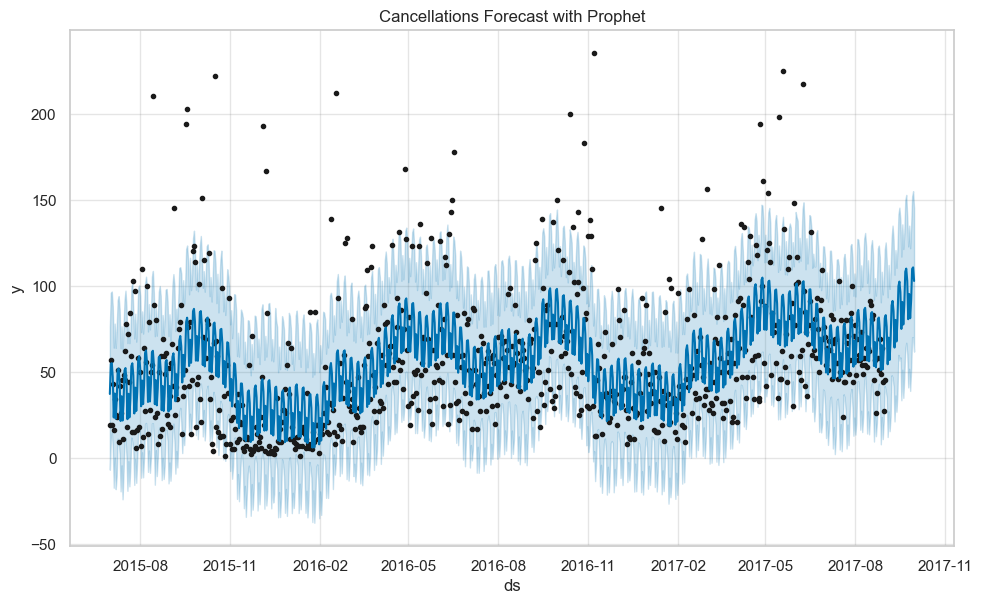

In [98]:
from prophet import Prophet
import pandas as pd

# Group by arrival_date and calculate cancellations
time_series = data.groupby('arrival_date')['is_canceled'].sum().reset_index()
time_series.columns = ['ds', 'y']  # Prophet requires columns 'ds' (date) and 'y' (value)

# Initialize and fit the Prophet model
model = Prophet()
model.fit(time_series)

# Create a future dataframe and make predictions
future = model.make_future_dataframe(periods=30)  # Predict for the next 30 days
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)
plt.title("Cancellations Forecast with Prophet")
plt.show()


Performance Comparison:
Prophet - MAE: 23.32605242642136, MSE: 1074.2321764674023
XGBoost/Logistic Regression - MAE: 42.78361511230469, MSE: 3131.478515625


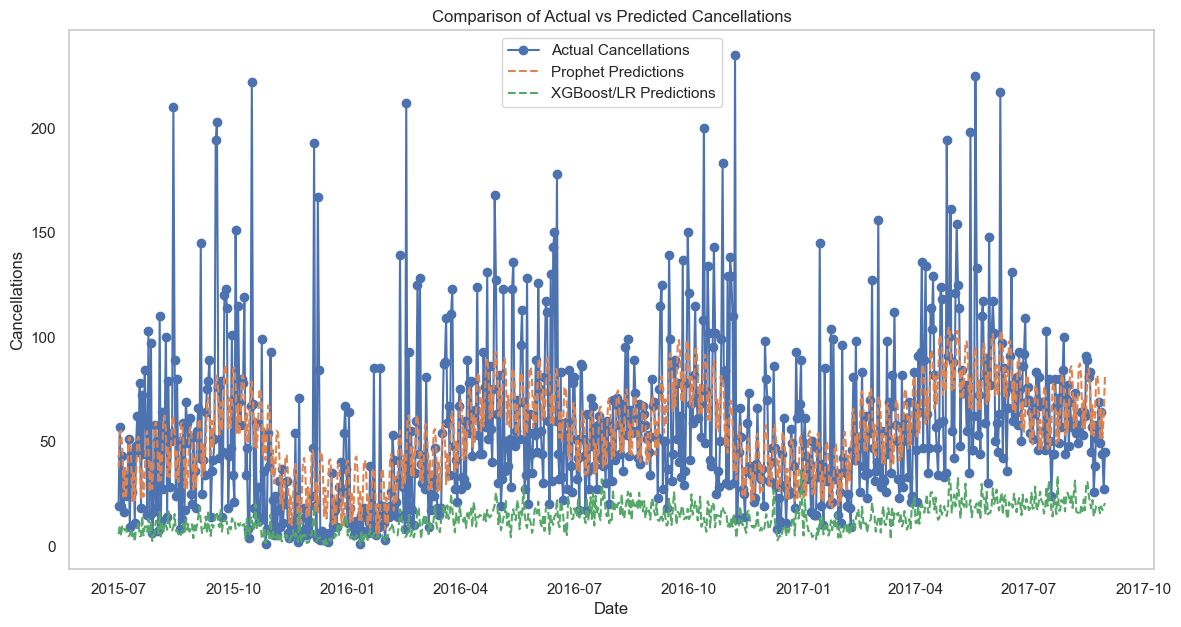

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Step 1: Prepare Prophet Predictions
prophet_actual = time_series
prophet_predictions = forecast[['ds', 'yhat']].copy()
prophet_predictions = prophet_predictions.merge(prophet_actual, on='ds', how='inner')

# Calculate Prophet metrics
prophet_mae = mean_absolute_error(prophet_predictions['y'], prophet_predictions['yhat'])
prophet_mse = mean_squared_error(prophet_predictions['y'], prophet_predictions['yhat'])

# Step 2: Prepare XGBoost and Logistic Regression Predictions
xgb_lr_predictions = X_test_with_predictions.copy()
xgb_lr_predictions['arrival_date'] = data.loc[X_test.index, 'arrival_date']

if 'is_canceled' not in xgb_lr_predictions.columns:
    print("Adding 'is_canceled' from the original data.")
    xgb_lr_predictions['is_canceled'] = data.loc[X_test.index, 'is_canceled']

xgb_lr_aggregated = xgb_lr_predictions.groupby('arrival_date').agg({
    'is_canceled': 'sum',  # Actual cancellations
    'Predicted_Probability': 'sum'  # Predicted cancellations
}).reset_index()

# Step 3: Merge Results for Comparison
comparison = prophet_predictions.merge(
    xgb_lr_aggregated,
    left_on='ds',
    right_on='arrival_date',
    suffixes=('_prophet', '_xgb_lr'),
    how='inner'
)

# Calculate XGBoost/Logistic Regression metrics
xgb_lr_mae = mean_absolute_error(comparison['y'], comparison['Predicted_Probability'])
xgb_lr_mse = mean_squared_error(comparison['y'], comparison['Predicted_Probability'])

# Step 4: Print Results
print("Performance Comparison:")
print(f"Prophet - MAE: {prophet_mae}, MSE: {prophet_mse}")
print(f"XGBoost/Logistic Regression - MAE: {xgb_lr_mae}, MSE: {xgb_lr_mse}")

# Step 5: Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(comparison['ds'], comparison['y'], label='Actual Cancellations', marker='o')
plt.plot(comparison['ds'], comparison['yhat'], label='Prophet Predictions', linestyle='--')
plt.plot(comparison['ds'], comparison['Predicted_Probability'], label='XGBoost/LR Predictions', linestyle='--')
plt.title("Comparison of Actual vs Predicted Cancellations")
plt.xlabel("Date")
plt.ylabel("Cancellations")
plt.legend()
plt.grid()
plt.show()


In [100]:
# Step 1: Prepare the Prophet model on the full dataset
time_series = data.groupby('arrival_date')['is_canceled'].sum().reset_index()
time_series.columns = ['ds', 'y']  # Prophet requires columns 'ds' (date) and 'y' (value)

# Initialize and fit the Prophet model
model = Prophet()
model.fit(time_series)

# Step 2: Create a future dataframe and make predictions
future = model.make_future_dataframe(periods=30)  # Adjust 'periods' based on prediction length
forecast = model.predict(future)

# Step 3: Merge Prophet predictions with the actual data
prophet_predictions = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]  # Extract relevant columns
prophet_predictions = prophet_predictions.merge(time_series, on='ds', how='left')  # Add actual cancellations

# Step 4: Save the predictions to a CSV file
output_file_path = "prophet_predictions.csv"
prophet_predictions.to_csv(output_file_path, index=False)

print(f"Prophet predictions saved to {output_file_path}")


21:45:17 - cmdstanpy - INFO - Chain [1] start processing
21:45:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet predictions saved to prophet_predictions.csv


In [101]:
import pandas as pd

# Step 1: Aggregate `is_canceled` in the original dataset
aggregated_data = data.groupby('arrival_date')['is_canceled'].sum().reset_index()
aggregated_data.columns = ['ds', 'actual_cancellations']

# Step 2: Align Prophet predictions with aggregated data
prophet_predictions = forecast[['ds', 'yhat']].copy()
merged_data = prophet_predictions.merge(aggregated_data, on='ds', how='left')

# Step 3: Optional - Convert Prophet predictions to binary (0 or 1) using a threshold
threshold = 10  # Define a reasonable threshold
merged_data['predicted_binary'] = (merged_data['yhat'] > threshold).astype(int)

# Step 4: Save the results to a CSV
output_file_path = "prophet_predictions_with_actuals.csv"
merged_data.to_csv(output_file_path, index=False)

print(f"Prophet predictions with actual values saved to {output_file_path}.")


Prophet predictions with actual values saved to prophet_predictions_with_actuals.csv.


In [102]:
%gui tk


In [103]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt

# Function to display charts for the selected model
def display_model_output():
    selected_model = model_selector.get()
    
    if selected_model == "XGBoost":
        display_xgboost_visuals()
    elif selected_model == "Prophet":
        display_prophet_visuals()
    elif selected_model == "Logistic Regression":
        display_logistic_visuals()
    elif selected_model == "Full Comparison Chart":
        display_comparison_chart()
    else:
        display_model_summary()

# Function to display XGBoost visualizations
def display_xgboost_visuals():
    clear_canvas()
    try:
        img1 = plt.imread(r"xgboost_comparision_data.png")
        img2 = plt.imread(r"xgboost_cm_data.png")
        
        fig, axs = plt.subplots(2, 1, figsize=(6, 8))
        axs[0].imshow(img1)
        axs[0].axis('off')
        axs[1].imshow(img2)
        axs[1].axis('off')
        fig.tight_layout()
        
        canvas = FigureCanvasTkAgg(fig, master=output_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    except Exception as e:
        messagebox.showerror("Error", f"Error displaying XGBoost visuals: {e}")

# Function to display Prophet visualizations
def display_prophet_visuals():
    clear_canvas()
    try:
        img = plt.imread(r"prophet_data_0.png")
        
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img)
        ax.axis('off')
        
        canvas = FigureCanvasTkAgg(fig, master=output_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    except Exception as e:
        messagebox.showerror("Error", f"Error displaying Prophet visuals: {e}")

# Function to display Logistic Regression visualizations
def display_logistic_visuals():
    clear_canvas()
    try:
        img1 = plt.imread(r"logistic_data.png")
        
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img1)
        ax.axis('off')
        
        canvas = FigureCanvasTkAgg(fig, master=output_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    except Exception as e:
        messagebox.showerror("Error", f"Error displaying Logistic Regression visuals: {e}")

# Function to display the full comparison chart
def display_comparison_chart():
    clear_canvas()
    try:
        img = plt.imread(r"comparision_data.png")
        
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img)
        ax.axis('off')
        
        canvas = FigureCanvasTkAgg(fig, master=output_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    except Exception as e:
        messagebox.showerror("Error", f"Error displaying the comparison chart: {e}")

# Function to display the model summary
def display_model_summary():
    clear_canvas()
    summary_text = (
        "Model Summary:\n\n"
        "1. XGBoost - Accuracy: 0.766 | ROC-AUC: 0.780\n"
        "2. Gradient Boosting - Accuracy: 0.760 | ROC-AUC: 0.762\n"
        "3. SVM - Accuracy: 0.759 | ROC-AUC: 0.726\n"
        "4. Random Forest - Accuracy: 0.754 | ROC-AUC: 0.762\n"
        "5. Logistic Regression - Accuracy: 0.648 | ROC-AUC: 0.719\n"
        "6. Naive Bayes - Accuracy: 0.355 | ROC-AUC: 0.659\n\n"
        "Performance Comparison:\n"
        "Prophet - MAE: 23.33, MSE: 1074.23\n"
        "XGBoost/Logistic Regression - MAE: 42.83, MSE: 3131.90"
    )
    summary_label = tk.Label(output_frame, text=summary_text, justify=tk.LEFT, font=("Arial", 12), anchor="w")
    summary_label.pack(fill=tk.BOTH, expand=True)

# Function to clear the canvas
def clear_canvas():
    for widget in output_frame.winfo_children():
        widget.destroy()

# Main app window
root = tk.Tk()
root.title("Model Visualizer")
root.geometry("800x600")

# Dropdown for model selection
model_selector = ttk.Combobox(
    root, 
    values=["XGBoost", "Prophet", "Logistic Regression", "Full Comparison Chart", "Other Models Summary"]
)
model_selector.set("Select a Model")
model_selector.pack(pady=10)

# Button to show visualizations or summary
show_button = tk.Button(root, text="Show Output", command=display_model_output)
show_button.pack(pady=10)

# Frame for displaying output
output_frame = tk.Frame(root, bg="white", bd=2, relief=tk.SUNKEN)
output_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

# Start the app
root.mainloop()
